In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
apartments_df = pd.read_csv("manhattan.csv")

numerical_features = ['bedrooms', 'bathrooms', 'size_sqft', 'min_to_subway', 'floor', 'building_age_yrs',
                      'no_fee', 'has_roofdeck', 'has_washer_dryer', 'has_doorman', 'has_elevator', 'has_dishwasher',
                      'has_patio', 'has_gym']

continuous_features = ['bedrooms', 'bathrooms', 'size_sqft', 'min_to_subway', 'floor', 'building_age_yrs']
continuous_idx = [numerical_features.index(col) for col in continuous_features]

# build tensors
X_all = torch.tensor(apartments_df[numerical_features].values, dtype=torch.float)
y_all = torch.tensor(apartments_df['rent'].values, dtype=torch.float).view(-1, 1)

# reproducible 80/20 train-validation split
torch.manual_seed(42)
num_samples = X_all.shape[0]
perm = torch.randperm(num_samples)
split_idx = int(0.8 * num_samples)
train_idx = perm[:split_idx]
val_idx = perm[split_idx:]

X_train = X_all[train_idx].clone()
X_val = X_all[val_idx].clone()
y_train = y_all[train_idx]
y_val = y_all[val_idx]

# scale continuous features using training statistics only
train_mean = X_train[:, continuous_idx].mean(dim=0, keepdim=True)
train_std = X_train[:, continuous_idx].std(dim=0, keepdim=True).clamp_min(1e-6)
X_train[:, continuous_idx] = (X_train[:, continuous_idx] - train_mean) / train_std
X_val[:, continuous_idx] = (X_val[:, continuous_idx] - train_mean) / train_std

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)

Train shape: torch.Size([2831, 14]) torch.Size([2831, 1])
Validation shape: torch.Size([708, 14]) torch.Size([708, 1])


: 

In [ ]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Linear(14, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

loss = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 500
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    train_predictions = model(X_train)
    train_mse = loss(train_predictions, y_train)
    train_mse.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_predictions = model(X_val)
        val_mse = loss(val_predictions, y_val)

    train_losses.append(train_mse.item())
    val_losses.append(val_mse.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}] | Train MSE: {train_mse.item():.4f} | Val MSE: {val_mse.item():.4f}")

Epoch [100/500] | Train MSE: 35979400.0000 | Val MSE: 34821000.0000
Epoch [200/500] | Train MSE: 30090998.0000 | Val MSE: 29072048.0000
Epoch [300/500] | Train MSE: 17326572.0000 | Val MSE: 16631026.0000
Epoch [400/500] | Train MSE: 8570659.0000 | Val MSE: 7785180.0000
Epoch [500/500] | Train MSE: 6042820.0000 | Val MSE: 5160576.5000


: 

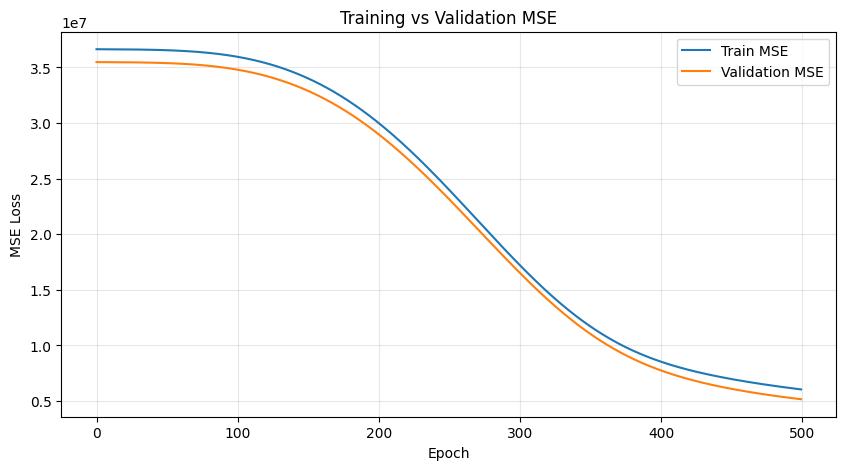

: 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses, label='Validation MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    train_preds = model(X_train)
    val_preds = model(X_val)

    train_rmse = torch.sqrt(loss(train_preds, y_train))
    val_rmse = torch.sqrt(loss(val_preds, y_val))

print(f"Train RMSE: ${train_rmse.item():,.2f}")
print(f"Validation RMSE: ${val_rmse.item():,.2f}")

Train RMSE: $2,455.02
Validation RMSE: $2,271.69


: 